# Simple model for $R_0$


$R_0$: "The average/expected number of secondary infections arising from a single individual during his or her entire infectious period, in a population of susceptibles" (Heffernan et al, 2005)

Goal: $R_0$ has not been reliably estimated for E. coli. With the available data set and likelihood-free inference tools, could we find this via simulation?


States:
- $C_s$: colonized by a specific E. coli strain of interest $s$.
- $I_s$: infected by e.coli (strain of interest or any?)
- $S$: susceptible to colonization by strain $s$. In other words, colonized by any other strain than $s$ or not colonized at all.

Parameters:
- $C_s$ -> S: Colonization by strain $s$ is "cleared", i.e, actually dissapears (caused for example by usage of antibiotics), or becomes replaced by another strain.
- $C_s$ -> I: Colonization develops into an infection
- (I -> $C_s$: Infected patient goes back to colonized state by strain $s$. Assumed to be neglible?)
- S -> $C_s$: susceptible individual is colonized by strain $s$
- I -> S: Infected patient goes back to susceptible state (maybe use of antibiotics clears the colonization? or the strain that infected the patient in the first place is not "strong enough" -> clearance.)

There should be a rate parameter for each of these transitions. They are then simulated using likelihood-free inference, more specifically the ELFI tool. (Lintusaari et al, 2018)

Through simulations, we can find the set of parameters that most closely matches the data. The inferred parameters can be used to determine $R_0$

The simulation will be SIR simulation, where $I$ is actually colonization rather than infection. We do not observe the colonization, but we do observe infection. 
- Step 1: SCR-simulation
- Step 2: "Translate" SCR to BSI using OR data.
- Step 3: Compare the translated BSI to demographic data.

Simplifications:
- Stratification by age groups: at first, no stratification, just see the evolvement of the entire population.
- One-vs-all approach to strains/CCs/STs

Simplifications can be expanded on later.

Future model configurations:
- Stratification by age group, complex strain dynamics
- IBM/ABM with one-vs-all strains. 
- Endgame: ABM with complex strain dynamics (c++?)



## Practicalities
To install to the correct python version, use `python3 -m pip install seaborn` otherwise will use some old Python v2. Do this via jupyter terminal. Also restart jupyter after installing packages, fixed "ModuleNotFound" error for me :)

Required packages (TODO: create anaconda environment ASAP)
- xlrd (to read excel files) DEPRECATED support for xlsx files, use `openpyxl` instead.

## How this works

- The foundation is the unobserved colonisation SIR model.
- The output of this model is then turned into BSI using `or_data`. This is the observational model part.
- Which is then compared with observed demographic data

Details:
- Consider non-colonisation too!

TODO: 
- Create a conversion function for turning the colonisation of the SIR model to BSI cases. This would be the observational model.
- Figure out how to do the BSI-ELFI SIR comparison - might require some trickery. **<- Difficult step**
- Exploratory analysis from the demographic data (assumed NORM/BSAC) OK

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [2]:
# load NORM data

norm_data = pd.read_excel("data/mmc2.xlsx", engine = 'openpyxl') # this is the NORM data


# load BSAC data
bsac_data = pd.read_csv("data/Supplemental_Data_S1.csv")


df = norm_data


# load babybiome data
or_data = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")

In [3]:
print("Total number of observations:", norm_data.shape[0])
print("ST131 observations:", norm_data.loc[norm_data['ST'] == 131].shape[0])

Total number of observations: 3254
ST131 observations: 272


## Preprocessing of the demographic data

In [4]:
bsac_data = bsac_data.rename(columns = {'Year_of_isolation':'year', 'MLST':'ST', 'Phylogroup':'clade'})

bsac_data.head()

,ERS accession,ERR accession,Collection,BSAC_or_CUH_number,year,Sequencing depth,ST,clade,serotype,H30Rx,...,oqxA_1_EU370913,oqxB_1_EU370913,qepA_1_AB263754,strA_1_M96392,strB_1_M96392,sul1_11_DQ914960,sul2_1_AF542061,sul3_2_AJ459418,tetA_2_X00006,tetB_3_AP000342
0,ERS357183,ERR435312,BSAC,eo100,2001,76.628483,68,D,NA:H6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tetB_4_AF326777
1,ERS357556,ERR434919,BSAC,eo1011,2005,78.691295,652,A,NA:H9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ERS357557,ERR434399,BSAC,eo1013,2005,84.620679,95,B2,O1:H7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ERS357558,ERR434695,BSAC,eo1014,2005,76.405329,73,B2,O6:H1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ERS357559,ERR434696,BSAC,eo1015,2005,75.694181,73,B2,O6:H1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
bsac_data['clade'].unique()

array(['D', 'A', 'B2', 'E', 'F', 'B1'], dtype=object)

Clade A does not represent ST131 in BSAC data. Probably makes sense, we are speaking of a different country.

In [6]:
def get_obs_BSI_ST(df, ST, as_prop = True):
    
    if as_prop:
        theta_BSI_obs_ST = pd.value_counts(df.loc[df['ST'] == ST]["year"])/pd.value_counts(df["year"]) # STX out of all STs in the data per year.
    else:
         theta_BSI_obs_ST = pd.value_counts(df.loc[df['ST'] == ST]["year"])
    
    return theta_BSI_obs_ST

def get_obs_BSI(df, clade, as_prop = True):
    # Get the proportion of clade out of all observations per year

    cladecol = 'CC131_clades'
    if 'clade' in df.columns:
        cladecol = 'clade'
        
    if as_prop:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"])/pd.value_counts(df["year"])# n clades per year/n all ST131 obs
    else:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"]) # these are counts directly
    
    return theta_BSI_obs

def get_obs_BSI_ST131(df, clade, as_prop = True):
    # Get the proportion of clade out of all ST131 observations per year
    
    df = df.loc[df['ST'] == 131] # clades known for ST131
    
    cladecol = 'CC131_clades'
    if 'clade' in df.columns:
        cladecol = 'clade'
        
    if as_prop:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"])/pd.value_counts(df["year"])# n clades per year/n all ST131 obs
    else:
        theta_BSI_obs = pd.value_counts(df.loc[df[cladecol] == clade]["year"]) # these are counts directly
    
    return theta_BSI_obs

data = bsac_data
clade = "A"
# Prop. clades out of all
print(f"Clade of interest: {clade}")
print(get_obs_BSI(data, clade, as_prop = False)) # automatically excludes years that have no observations
print(get_obs_BSI(data, clade, as_prop = False))
print(sum(get_obs_BSI(data, clade, as_prop = False))) # total number of 'clade' observations

# Prop. ST
print("ST131:")
#print(get_obs_BSI_ST(data, 131, as_prop = False))
#print(get_obs_BSI_ST(data, 131))
print(sum(get_obs_BSI_ST(data, 131, as_prop = False))) # total number of ST131 observations
# TODO: how to handle missing values

# All data per year, N
print("All data")
#print(pd.value_counts(data["year"]))
print(sum(pd.value_counts(data["year"]))) # total number of observations

# All but ST131 observations
print("All but ST131")
print(sum(pd.value_counts(data["year"])) - sum(get_obs_BSI_ST(data, 131, as_prop = False)))

# All but clade X observations
print(f"All but clade {clade}")
print(sum(pd.value_counts(data["year"])) - sum(get_obs_BSI(data, clade, as_prop = False)))

print(f"Just clade {clade}")
print(sum(get_obs_BSI(data, clade, as_prop = False)))

# Exact matches with OR data:
# - NORM clade A

# Big mismatches:
# - BSAC clade A. Found 130 obs, other obs 1379. In OR data, 19/1490.

Clade of interest: A
2011    18
2007    17
2003    13
2006    12
2008    12
2009    11
2005    10
2002    10
2010    10
2001     9
2012     5
2004     3
Name: year, dtype: int64
2011    18
2007    17
2003    13
2006    12
2008    12
2009    11
2005    10
2002    10
2010    10
2001     9
2012     5
2004     3
Name: year, dtype: int64
130
ST131:
218
All data
1509
All but ST131
1291
All but clade A
1379
Just clade A
130


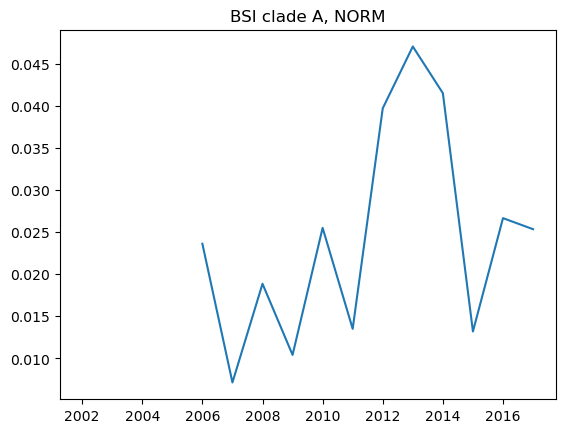

In [7]:
# Visualize the observed data
data = norm_data
clade = 'A'
dataname = "NORM"

plt.plot(get_obs_BSI(data, clade).index, get_obs_BSI(data, clade))
plt.title(f"BSI clade {clade}, {dataname}")
plt.show()

## Replicating Odds Ratio calculations


Invasiveness is the ratio of the frequencies of carriage (newborns) and disease (BSI).


OR = (c0/d0)/(ca/da) = da/ca * c0/d0 = (da/ca)/(d0/c0)


$$OR = \frac{inv_a}{inv_0} = \frac{\frac{d_a}{c_a}}{\frac{d_0}{c_0}} = \frac{d_ac_0}{c_ad_0}$$

Odds ratio is calculated between `PP` and `nonPP`. PP = popPUNK. PP = clade A, nonPP = not clade A for example. 

Rebecca's message: 

$$OR = \frac{inv_a}{inv_0} = \frac{d_ac_0}{c_ad_0},$$ where $a = $ clade A for example, and zero means non-clade A.

Now it makes sense!

**Q**: Why are there more disease than carriage cases? **A**: Different data. Carriage from the babybiome data, so only a sample of newborns.


In [8]:
# some tests


# required knowledge:
N = 10000  # from demographic data
Nc = N - 4000 # from SIR simulation

# voidaan laskea datasta suoraan. TODO seuraavaksi.
Nbsi = N - 2000 # from NORM, we know all the infections (at each time point though?? What is the resolution? The data I have is yearly.)
N_bsi_A = 500 # Known from NORM
N_bsi_0 = Nbsi - N_bsi_A
# Case 1: Nbsi > Nc

theta_c = Nc/N
theta_bsi = Nbsi/N

print("theta_c:", theta_c, "theta_bsi:", theta_bsi)

N_c_A = 1000
N_c_0 = Nc - N_c_A

print(N_c_A, N_c_0)

print("Carriage:")

print("theta_c_A = N_c_A/N:", N_c_A/N)

print("theta_c_0", theta_c - N_c_A/N)
print("theta_c_0", N_c_0/N)

print("theta_c_A = N_c_A/Nc:", N_c_A/Nc)

print("theta_c_0", 1 - N_c_A/Nc)
print("theta_c_0", N_c_0/Nc)

print("Disease:")

print("theta_bsi_A = N_bsi_A/N:", N_bsi_A/N)

print("theta_bsi_0", theta_bsi - N_bsi_A/N)

print("theta_bsi_A = N_bsi_A/Nbsi:", N_bsi_A/Nbsi)

print("theta_bsi_0", theta_bsi - N_bsi_A/Nbsi)
print("theta_bsi_0", N_bsi_0/Nbsi)


# TODO formulate this as a reasonable question.


theta_c: 0.6 theta_bsi: 0.8
1000 5000
Carriage:
theta_c_A = N_c_A/N: 0.1
theta_c_0 0.5
theta_c_0 0.5
theta_c_A = N_c_A/Nc: 0.16666666666666666
theta_c_0 0.8333333333333334
theta_c_0 0.8333333333333334
Disease:
theta_bsi_A = N_bsi_A/N: 0.05
theta_bsi_0 0.75
theta_bsi_A = N_bsi_A/Nbsi: 0.0625
theta_bsi_0 0.7375
theta_bsi_0 0.9375


In [9]:
print(bsac_data.shape)
print(norm_data.shape)

(1509, 407)
(3254, 63)


In [10]:

print(or_data.columns)
print(or_data.head(10))

print((or_data['carriage_nonPP']/or_data['Disease_nonPP'])/(or_data['carriage_PP']/or_data['Disease_PP'])) # this is how the OR is calculated.
#print(or_data["OR"]) # to check

# disease_nonPP + diseasePP = number of observations in BSAC/NORM

Index(['Collection', 'Clade', 'Label', 'carriage_nonPP', 'Disease_nonPP',
       'carriage_PP', 'Disease_PP', 'OR', 'lower', 'upper', 'pval_f<=5_chi>5',
       'p.adj BH'],
      dtype='object')
  Collection Clade          Label  carriage_nonPP  Disease_nonPP  carriage_PP  \
0       NORM     A       A (NORM)             387           3179           16   
1       BSAC     A       A (BSAC)             387           1490           16   
2   Combined     A   A (Combined)             387           4669           16   
3       NORM     B       B (NORM)             389           3172           14   
4       BSAC     B       B (BSAC)             389           1464           14   
5   Combined     B   B (Combined)             389           4636           14   
6       NORM    C1      C1 (NORM)             399           3184            4   
7       BSAC    C1      C1 (BSAC)             399           1487            4   
8   Combined    C1  C1 (Combined)             399           4671            

# ELFI

Clade of interest vs all. So baseline/defnition of a susceptible population = no clade X colonization.

[ELFI documentation](https://elfi.readthedocs.io/en/latest/)

Components in ELFI graph
- TODO: Simulators, summaries etc.

Local installation:
- `pip3 install elfi`


The objective: First simulate colonization with an SCR model (SIR, but I = colonization). Then use an observational model to "translate" colonization to BSI. Then compare this "translated" BSI to the colonization.

### Questions
- What is the subject indicator here? Is there only one sample per subject?
- On what level are we modelling, subject or just observations? How to define "missingness" of some ST colonization if we don't have time series data from a single subject?

In [11]:
import elfi

warning in stationary: failed to import cython module: falling back to numpy
warning in coregionalize: failed to import cython module: falling back to numpy
warning in choleskies: failed to import cython module: falling back to numpy


# Converting simulated colonization to BSI

Estimate of OR: $N(OR, \sigma)$ 

Invasiveness of E.coli is calculated as follows:

$inv = \frac{f_{disease}}{f_{carriage}}$

What to do:
- Simulate colonization with SIR model
- Convert colonization to BSI via OR data
- Compare converted BSI with the data.
- Enjoy!!!


Note that invasiveness =/= force of colonization

Base carriage rate for E.coli is assumed constant over time and over all age groups.


OR = 2 means that clade B is twice as likely to cause BSI non-B clades.

### Derivation of $\theta_{BSI, A}$ from the odds ratios

$\theta_{C,A}$ is the proportion of individuals colonized by clade A. 
Here A = clade A and 0 = other clades. BSI = blood stream infection, C = carriage.

The derivation:


$$\hat{OR} = \frac{inv_A}{inv_0} = \frac{\theta_{BSI,A}\theta_{C,0}}{\theta_{C,A}\theta_{BSI,0}}$$

$$\hat{OR}\theta_{C,A}\theta_{BSI,0} = \theta_{BSI,A}\theta_{C,0}$$

$$\theta_{BSI,A} = \frac{\hat{OR}\theta_{C,A}\theta_{BSI,0}}{\theta_{C,0}}$$


Known quantities from the data: $\theta_{BSI, A}$, $\theta_{BSI,0}$.  $\theta_{C,0}$ is known through the known parameter $\theta_{C}$ which represents the proportion of colonized individuals of the entire population.
OR is simulated based on the odds ratios.

Problem: how to get $\theta_{BSI,0}$

OR is simulated as follows:

$$\hat{OR} \sim N(0.5, 0.1)$$

I then use $\theta_{C,A}$ as $I$ compartment observations and $\theta_{C,0}$ (derived similarly) as $S$ comparment observations. **<- legal?**

**Alternative: counts**

Assumptions: 
- We know the number of colonized individuals (by any E.coli strain)
- Assume that $\theta_{x,A} = \frac{N_{x,A}}{N}$, where $N$ is the population of interest (for example entire Norway or an age group)
- $N_{X,0} = N_{X} - N_{X,A}$

$$OR = \frac{N_{BSI,A}}{N}\frac{N}{N_{C,A}}\frac{N_{C,0}}{N}\frac{N}{N_{BSI,0}}$$
$$OR = \frac{N_{BSI,A}}{N_{C,A}}\frac{N_{C,0}}{N_{BSI,0}}$$
$$OR = \frac{N_{BSI,A}}{N_{C,A}}\frac{N_{C,0}}{N_{BSI} - N_{BSI, A}}$$
$$OR = \frac{N_{BSI,A}}{N_{C,A}}\frac{N_{C} - N_{C,A}}{N_{BSI} - N_{BSI, A}}$$
$$ORN_{BSI} - ORN_{BSI, A} = \frac{N_{BSI,A}}{N_{C,A}}(N_{C} - N_{C,A})$$
$$ORN_{BSI} - ORN_{BSI, A} = \frac{N_{BSI,A}N_{C} - N_{BSI,A}N_{C,A}}{N_{C,A}}$$
$$ORN_{BSI}N_{C,A} - ORN_{BSI, A}N_{C,A} = N_{BSI,A}N_{C} - N_{BSI,A}N_{C,A}$$
$$ ORN_{BSI, A}N_{C,A} + N_{BSI,A}N_{C} - N_{BSI,A}N_{C,A} = ORN_{BSI}N_{C,A}$$
$$ N_{BSI, A}(ORN_{C,A} + N_{C} - N_{C,A}) = ORN_{BSI}N_{C,A}$$
$$ N_{BSI, A} = \frac{ORN_{BSI}N_{C,A}}{ORN_{C,A} + N_{C} - N_{C,A}}$$


### Thoughts on the population size N

There are two alternative interpretations:


**a)** $\theta_{C, A} = \frac{N_{C,A}}{N}$

**b)** $\theta_{C, A} = \frac{N_{C,A}}{N_{C}}$


When considering the OR, this choice does not matter since $N$ (or $N_C$) cancels out. In both cases, the following hold:

$$N_C = N_{C,A} + N_{C,0}$$

$$\theta_C = \frac{N_C}{N}$$

The difference is as follows:

**Option a)**, population is $N$ (one age group or for example the entire population of Norway.


$N_C = N_{C,A} + N_{C,0}$

$\theta_CN = \theta_{C,A}N + \theta_{C,0}N$  Divide this by $N$

$\theta_C = \theta_{C,A} + \theta_{C,0}$

**Option b)**, We consider the proportion of clade A colonizations to be from all colonizations, not the entire population

$N_C = N_{C,A} + N_{C,0}$

$N_C = \theta_{C,A}N_C + \theta_{C,0}N_C$  Divide this by $N_C$

$\theta_{C,A} + \theta_{C,0} = 1$




Current implementation supports both options with the `theta_c` parameter. Input 1 to use option a) and `theta_c < 1` to use option b).


**Obvious restrictions:**
- $\theta_{C,X}$ <= $\theta_C$
- $\theta_{C,A} + \theta_{C,0} <= 1$

In [12]:
or_data.head()

,Collection,Clade,Label,carriage_nonPP,Disease_nonPP,carriage_PP,Disease_PP,OR,lower,upper,pval_f<=5_chi>5,p.adj BH
0,NORM,A,A (NORM),387,3179,16,75,0.5706,0.3292,0.9890,0.0429,0.1287
1,BSAC,A,A (BSAC),387,1490,16,19,0.3084,0.1571,0.6054,0.0003,0.0018
2,Combined,A,A (Combined),387,4669,16,94,0.4870,0.2837,0.8357,0.0077,0.0308
3,NORM,B,B (NORM),389,3172,14,82,0.7183,0.4036,1.2784,0.2585,0.3878
4,BSAC,B,B (BSAC),389,1464,14,45,0.8541,0.4640,1.5721,0.6120,0.6303


In [13]:
print(or_data['Clade'].unique())

clade = "A"
dataset = "NORM"

df = or_data[or_data["Label"] == f'{clade} ({dataset})']
print(df)
or_mu = df["OR"]
or_sd = (df["upper"] - df["lower"])/2
print(or_sd)
print(len(or_sd))
print(or_mu)

['A' 'B' 'C1' 'C2' 'ST131']
  Collection Clade     Label  carriage_nonPP  Disease_nonPP  carriage_PP  \
0       NORM     A  A (NORM)             387           3179           16   

   Disease_PP      OR   lower  upper  pval_f<=5_chi>5  p.adj BH  
0          75  0.5706  0.3292  0.989           0.0429    0.1287  
0    0.3299
dtype: float64
1
0    0.5706
Name: OR, dtype: float64


## Observational model

**Assumptions**
- Fully colonized population. Can be changed by tweaking $\theta_c$.
- $\theta_{BSI,0} + \theta_{BSI,A} = 1$


**Other**
- This should by default support stratification by age groups: simply change the parameters to reflect the age group of interest

Dummy data, theta_bsi = 1, theta_c = 1


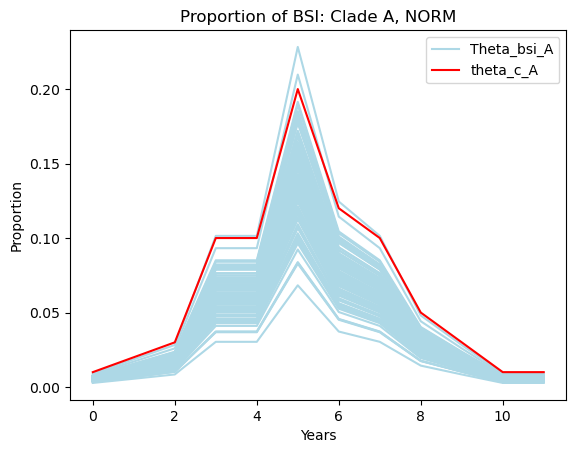

Dummy data, extreme peak, theta_bsi = 1, theta_c = 1


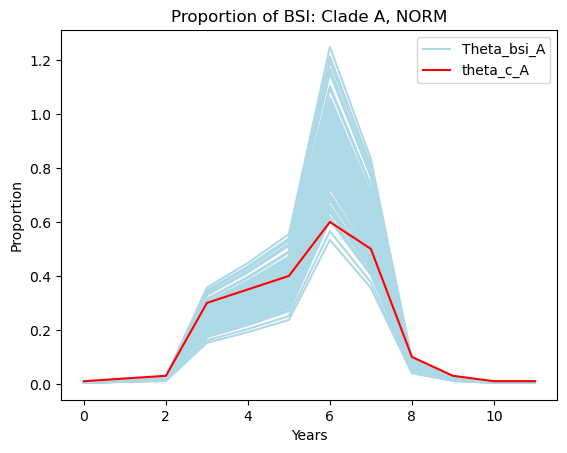

Dummy data, random colonization, theta_bsi = 1, theta_c = 1


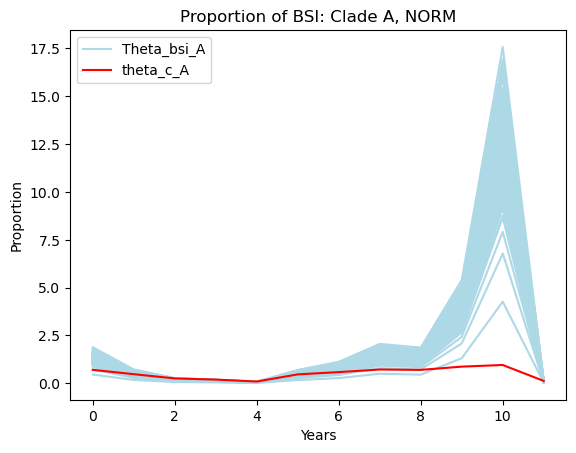

In [14]:
# Observational model


clade = "A"
dataset = "Combined"

df = or_data[or_data["Label"] == f'{clade} ({dataset})']
nt = 100 # number of observed time points (years or weeks? Observed data in years.)

def col_to_BSI(theta_c_a, or_data = or_data, clade = "A", dataset = "NORM", theta_c = 1, theta_bsi = 1):
    # theta_c_a: SIR simulator clade of interest colonization proportion over time
    # theta_bsi: The proportion of bsi in the entire (colonized) population (this should be known to us)
    # theta_c: The overall proportion of population colonized by E. coli. For simplicity, assume we are only interested in the colonized 
    # population and set theta_c = 1 by default.
    
    # Q: OR data is not time series. What to do? Oh, it does not matter since theta_c_a is time series.
    
    n_obs = len(theta_c_a[0]) # with batches. 0 = first batch
    
    bs = len(theta_c_a)
    #theta_c = np.array([theta_c]*n_obs)

    # choose the clade and dataset
    df = or_data[or_data["Label"] == f'{clade} ({dataset})']
    
    # relevant quantities from data
    #theta_c_a = float(df["carriage_PP"]/(df["carriage_nonPP"] + df["carriage_PP"])) # carriage rate of c as from the data.
    #theta_c_0 = float(df["carriage_nonPP"]/(df["carriage_nonPP"] + df["carriage_PP"]))
    theta_bsi_a = float(df["Disease_PP"]/(df["Disease_nonPP"] + df["Disease_PP"])) # if defined like this, then theta_bsi = 1.
    theta_bsi_0 = float(df["Disease_nonPP"]/(df["Disease_nonPP"] + df["Disease_PP"]))
    
    # odds ratios from a normal distribution for a bit of uncertainty (based on data)
    or_mu = df["OR"]
    or_sd = (df["upper"] - df["lower"])/2
    OR_hat = np.array([np.random.normal(or_mu, or_sd**2, 1)]*bs) # here just one OR taken for a given simulation.

    # get the relevant observed quantities
    #print("Shape of OR_hat:", OR_hat.shape)
    theta_bsi_a_hat = (OR_hat*theta_c_a*theta_bsi_0)/(theta_c - theta_c_a) # Both should be below 1!
    #theta_bsi_0_hat = (theta_bsi_a*theta_c_0)/(OR_hat*theta_c_a)
    theta_bsi_0_hat = theta_bsi - theta_bsi_a_hat#(theta_bsi_a*(theta_c - theta_c_a))/(OR_hat*theta_c_a)
    #theta_c_a_obs = theta_bsi_a*theta_c_0/(OR_hat*theta_bsi_0) # this is now I_obs!
    #theta_c_0_obs = OR_hat*theta_c_a*theta_bsi_0/theta_bsi_a # This is S_obs!
    #print(theta_bsi_a_hat)
    return theta_bsi_a_hat
    #return np.array([theta_bsi_a_hat]), np.array([theta_bsi_0_hat]) # same as S (not colonized by clade of interest) and I (colonized by clade of interest) compartment from the simulation


theta_c_a = np.array([[0.01, 0.02, 0.03, 0.1, 0.1,0.2, 0.12, 0.1, 0.05, 0.03, 0.01, 0.01],\
                      [0.01, 0.02, 0.03, 0.1, 0.1,0.2, 0.12, 0.1, 0.05, 0.03, 0.01, 0.01]]) # testdata, close to BSI
theta_c_a2 = np.array([[0.01, 0.02, 0.03, 0.3, 0.35,0.4, 0.6, 0.5, 0.1, 0.03, 0.01, 0.01],\
                      [0.01, 0.02, 0.03, 0.3, 0.35,0.4, 0.6, 0.5, 0.1, 0.03, 0.01, 0.01]]) # testdata, more extreme peak

import random

rand_col = [random.uniform(0,1) for i in range(0, 12)]
theta_c_a3 = np.array([rand_col, rand_col]) # testdata, purely random

#theta_c_0 = np.array([1]*len(theta_c_a)) - theta_c_a
col_to_BSI(theta_c_a, or_data, "A", "NORM")

# pitääkö havaintojen määrän olla sama kuin simuloitujen havaintojen määrä? Nimittäin meillä on vain vuosittaiset havainnot. A: ei varmaan väliä.

# Plot how the uncertainty in OR affects the results

clade = "A"
dataset = "NORM"
n_rep = 100



def plot_col_to_BSI(theta_c_a, or_data = or_data, clade = "A", dataset = "NORM", n_rep = 100):
    # Plot n_rep repetitions of theta_BSI_clade as "translated" from colonization by clade of interest.
    
    for i in range(0, n_rep):
        obsBSI = col_to_BSI(theta_c_a, or_data, clade, dataset)
        if i == 0:
            plt.plot(obsBSI[0], color = "lightblue", label = "Theta_bsi_A")
        else:
            plt.plot(obsBSI[0], color = "lightblue")

    plt.plot(theta_c_a[0], color = "red", label = "theta_c_A")
    # TODO: plot the mean line of the repetitions
    plt.title(f"Proportion of BSI: Clade {clade}, {dataset}")
    plt.xlabel("Years")
    plt.ylabel("Proportion")
    plt.legend()
    plt.show()

print(f"Dummy data, theta_bsi = 1, theta_c = 1")
plot_col_to_BSI(theta_c_a, or_data, clade = "A", dataset = "NORM")

print(f"Dummy data, extreme peak, theta_bsi = 1, theta_c = 1")
plot_col_to_BSI(theta_c_a2, or_data, clade = "A", dataset = "NORM")

print(f"Dummy data, random colonization, theta_bsi = 1, theta_c = 1")
plot_col_to_BSI(theta_c_a3, or_data, clade = "A", dataset = "NORM")


# Problems: 
# - theta_bsi_a can now be more than 1, check random colonization and extreme peaks TODO fix


# "Biological" requirements/assumptions:
# - If all hosts are colonized by clade A, then all BSIs are caused by clade A. (theta_c_a = 1 -> theta_BSI_a = 1)
# - If no host is colonized by clade A, then no BSI should be caused by clade A. (theta_c_a = 0 -> theta_BSI_a = 0)
# - theta_X <= 1 (we are working with proportions; no proportion should be more than 1.)

# SIR model with ELFI

Currently using SMC-ABC with adaptive threshold. 

Thoughts:
- ELFI can handle a SIR model with multiple outputs (S, I, R counts namely)
    - Diagnosis: it can run, but will not yield correct results, at least not for a simple SIR model :)
    - It got beta right, but screwed up gamma
- Testing: return only the number of infected cases from `simpleSIR`
    - Now it gets gamma roughly right but not beta...
    - Adding more summary statistics worked

Lintusaari et al 2017:
- Tuberculosis example: number of infectious hosts used as the "y" here. Summary statistics based on genetic diversity and number of clusters (cluster = closely related strains(?))

McKinley et al 2009: 
- Epidemic models often have a lot of correlation between params
- Prior knowledge can for example be the length of infectious period determined in a previous study

Thoughts on the summary statistic:
- Mean number of infectious hosts is probably not the best, especially since the oserved data is simulated until all are in the R category. Solution: use observations up to a predefined number of infetious hosts, like 50. Solution 2: use something else as the summary statistic. Maybe even maximum number of infected/infectious hosts during the simulation?
- What if I attempt to use S and R as well for summary statistics?

Assumptions
- Constant population size $N$ seems reasonable, given how short a time period we are using
- Constant $\beta$ and $\gamma$ (does this make sense?)
- Homogeneous mixing of population (does not really hold, especially if we consider age structure etc demographics later on)


### SIR model in terms of proportions:

$$\frac{d\theta_S(t)}{dt} = -\beta\theta_S(t)\theta_I(t)$$

$$\frac{d\theta_I(t)}{dt} = \beta\theta_S(t)\theta_I(t) - \alpha\theta_I(t)$$

$$\frac{d\theta_R(t)}{dt} = \alpha\theta_I(t)$$

In [15]:
# True value for theta_BSI, A from the data:

df = pd.read_csv("data/ST131_clades_OR_E_coli_carriage_disease_collapsed.csv")


clade = "A"
data = "Combined"
print(f'{clade} ({data})')
theta_BSI_a_true = df[df["Label"] == f'{clade} ({data})']["Disease_PP"]/(df[df["Label"] == f'{clade} ({data})']["Disease_PP"] + df[df["Label"] == f'{clade} ({data})']["Disease_nonPP"])
theta_BSI_a_true

# The estimated value is way too small but yeehaw, it makes at least somewhat sense :)

A (Combined)


2    0.019735
dtype: float64

In [18]:
def prop_bsi_a(thetaI, theta_C, theta_BSI, mu_OR, var_OR, OR_size = 1000):
    
    theta_a = np.max(thetaI) # I compartment, here carriage. At maximum, just because - change later.
    theta_0 = theta_C - theta_a
    
    OR_hat = np.random.normal(mu_OR, var_OR, size = OR_size) # get the OR
    
    theta_BSI_a = OR_hat*theta_BSI*theta_a/(theta_0 + OR_hat*theta_a)
    #theta_BSI_a = OR_hat*theta_a/(OR_hat*theta_a + theta_0)
    
    #plt.hist(theta_BSI_a)
    #plt.show()
    
    return theta_BSI_a

def dS(S, I, t, beta, N, is_prop = False):
    
    if is_prop:
        return -beta*S[:,t]*I[:,t]
    return -beta*S[:,t]*I[:,t]/N[t]

def dI(I, S, t,beta, gamma, N, is_prop = False):
    
    if is_prop:
        return beta*S[:,t]*I[:,t] - gamma*I[:,t]
    return beta*S[:,t]*I[:,t]/N[t] - gamma*I[:,t]

def dR(I, t, gamma):
    
    return gamma*I[:,t]

def propSIR_simulator(beta, gamma, is_bsi = True, is_prop = True, batch_size = 1, random_state = None):
    # SIR model with proportions
    
    bsi_params = {"theta_C":0.6, "theta_BSI": 0.05, "mu_OR":0.4, "var_OR":0.6, "OR_size":100}
    params = {"S0": 100000 - 1, "I0": 1, "R0":0, "times":[i for i in range(0,104)],"timestep":1, "N":100000}
    N = np.array([params["N"]]*len(params["times"]))
    
    thetaS = np.zeros((batch_size, len(params["times"])))
    thetaI = np.zeros((batch_size, len(params["times"])))
    thetaR = np.zeros((batch_size, len(params["times"])))
    
    thetaS[:,0] = params["S0"]
    thetaI[:,0] = params["I0"]
    thetaR[:,0] = params["R0"]
    
    #thetaS = [params["S0"]]
    #thetaI = [params["I0"]]
    #thetaR = [params["R0"]]
    
    if is_prop:
        thetaS[:,0] = thetaS[:,0]/N[0] # recommendation: make S0 the same as N - I0
        thetaI[:,0] = thetaI[:,0]/N[0]
        thetaR[:,0] = thetaR[:,0]/N[0]
    
    #beta = params["beta"]
    #gamma = params["gamma"]
    

    for t in params["times"][:-1]:

        #dthetaS = -beta*thetaS[t]*thetaI[t]
        #dthetaI = beta*thetaS[t]*thetaI[t] - gamma*thetaI[t]
        #dthetaR = gamma*thetaI[t]
        #if np.isclose(thetaI[t],0): # if the number of infected individuals reaches zero (or almost zero), then stop simulating.
            #break

        #if any(thetaS[:,t]) > N[0]: #Constant population size assumed here!
            #print("S > N, stopping simulation")
            #break

        thetaS[:,t + 1] = thetaS[:,t] + dS(thetaS, thetaI, t, beta, N, is_prop = is_prop)
        thetaI[:,t + 1] = thetaI[:,t] + dI(thetaI, thetaS, t, beta, gamma, N, is_prop = is_prop)
        thetaR[:,t + 1] = thetaR[:,t] + dR(thetaI, t, gamma)

        #thetaS.append(thetaS[t] + dS(thetaS, thetaI, t, beta, N, is_prop = is_prop))
        #thetaI.append(thetaI[t] + dI(thetaI, thetaS, t, beta, gamma, N, is_prop = is_prop))
        #thetaR.append(thetaR[t] + dR(thetaI, t, gamma))

    print(thetaI.shape)
    if is_bsi:
        #return prop_bsi_a(thetaI, bsi_params["theta_C"], bsi_params["mu_OR"], bsi_params["var_OR"], bsi_params["OR_size"])
        return col_to_BSI(thetaI, or_data, clade = "A", dataset = "NORM", theta_c = 1, theta_bsi = 0.2) # should be batch compatible
    else:
        # create batches. Same params for the SIR simulation always yield the same sequence.
        #thetaS = np.array([thetaS for b in range(0,batch_size)])
        #thetaI = np.array([thetaI for b in range(0, batch_size)])
        #thetaR = np.array([thetaR for b in range(0, batch_size)])
        
        return thetaS, thetaI #, thetaR
    

def SIR_simulator(beta, gamma, nt = 104, batch_size = 1, random_state = None):
    
    thetaIs = np.empty((batch_size, nt))
    print(thetaIs.shape)
    for i in range(0, batch_size):
        print("Call propSIR")
        


Data is in the format $(S, I)$, where $S = n x n_{batch}$ and $I = n x n_{batch}$

(3, 104)
(1, 104)


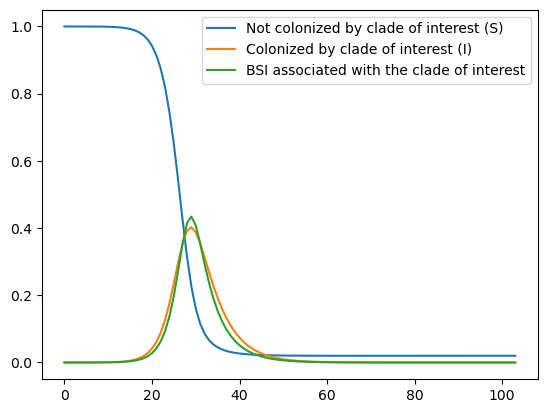

In [19]:
y = propSIR_simulator(beta = 0.72, gamma = 0.2, is_bsi = False, is_prop = True, batch_size = 3) # colonization
y_bsi = propSIR_simulator(beta = 0.72, gamma = 0.2, is_bsi = True, is_prop = True, batch_size = 1) # infection
#print(y[0][0]) # S and 1st batch

#print(y)
# Plot some simulated colonization and then BSI as determined from that colonization
plt.plot(y[0][0], label = "Not colonized by clade of interest (S)")
plt.plot(y[1][0], label = "Colonized by clade of interest (I)")
plt.plot(y_bsi[0], label = "BSI associated with the clade of interest")
plt.legend()
plt.show()

(3, 104)


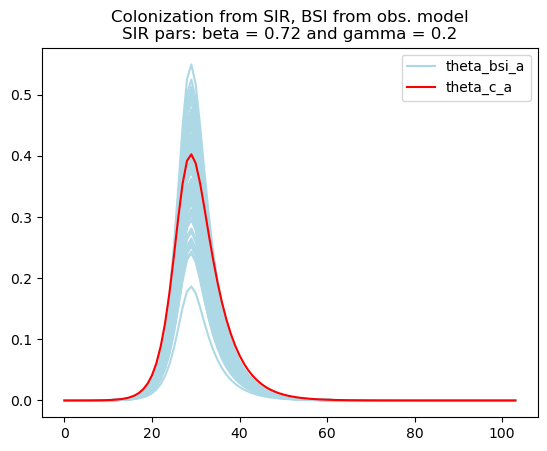

In [24]:
# Conversion of colonization to BSI; test
y = propSIR_simulator(beta = 0.72, gamma = 0.2, is_bsi = False, is_prop = True, batch_size = 3)
col = y[1] # colonized by clade of interest


for i in range(0, n_rep):
    bsi = col_to_BSI(col, or_data, clade = "A", dataset = "NORM", theta_c = 1, theta_bsi = 0.2)
    if i == 0:
        plt.plot(bsi[0], color = "lightblue", label = "theta_bsi_a")
    else:
        plt.plot(bsi[0], color = "lightblue")
plt.plot(col[0], color = "red", label = "theta_c_a")

plt.title("Colonization from SIR, BSI from obs. model\nSIR pars: beta = 0.72 and gamma = 0.2")
plt.legend()
plt.show()

# There is a lot of variation here (due to randomness in OR)

In [20]:
# Distance metrics

def I_mean(y):
    return np.mean(y[1][:,], axis=1)

def I_var(y):
    return np.var(y[1][:,], axis=1)


def S_min(y):
    return np.min(y[0][:,], axis=1)

def R_max(y):
    return np.max(y[2][:,], axis=1)


def I_mean_bsi(y):
    return np.mean(y[:,], axis = 1).reshape(-1,1)

def I_var_bsi(y):
    return np.var(y[:,], axis = 1).reshape(-1,1)

In [21]:
y = propSIR_simulator(beta = 0.72, gamma = 0.2, is_bsi = True, is_prop = True, batch_size = 3)

print(y) # (batch_size, n_obs)

[batch[~np.isnan(batch)]for batch in y]
bsi_obs = get_obs_BSI(df = norm_data, clade = "A")
print(bsi_obs)

bsi_obs[~np.isnan(bsi_obs)]

(3, 104)
[[4.85765859e-06 7.38364448e-06 1.12231369e-05 1.70591456e-05
  2.59298248e-05 3.94131196e-05 5.99073903e-05 9.10578726e-05
  1.38404691e-04 2.10367360e-04 3.19740122e-04 4.85962292e-04
  7.38563222e-04 1.12238481e-03 1.70548744e-03 2.59109146e-03
  3.93555030e-03 5.97524672e-03 9.06645761e-03 1.37434589e-02
  2.08006289e-02 3.14013644e-02 4.72022487e-02 7.04331125e-02
  1.03740092e-01 1.49297026e-01 2.06302257e-01 2.66626724e-01
  3.12799553e-01 3.27160157e-01 3.07546837e-01 2.67476057e-01
  2.22107474e-01 1.80158389e-01 1.44659110e-01 1.15779703e-01
  9.26702096e-02 7.42819554e-02 5.96589388e-02 4.80109248e-02
  3.87093467e-02 3.12614840e-02 2.52825753e-02 2.04717961e-02
  1.65931272e-02 1.34605918e-02 1.09269920e-02 8.87533262e-03
  7.21227024e-03 5.86308306e-03 4.76778399e-03 3.87809716e-03
  3.15509160e-03 2.56731818e-03 2.08933540e-03 1.70053736e-03
  1.38421832e-03 1.12682364e-03 9.17348059e-04 7.46851437e-04
  6.08067959e-04 4.95090439e-04 4.03114843e-04 3.28233327e-04

2002    0.024096
2004    0.008000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64

Potential summaries:
- Time of the max proportion of colonized hosts

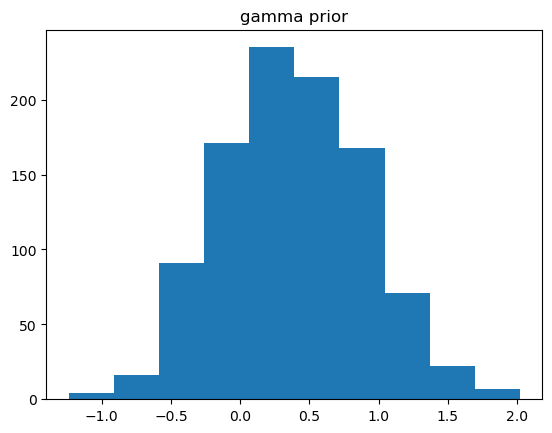

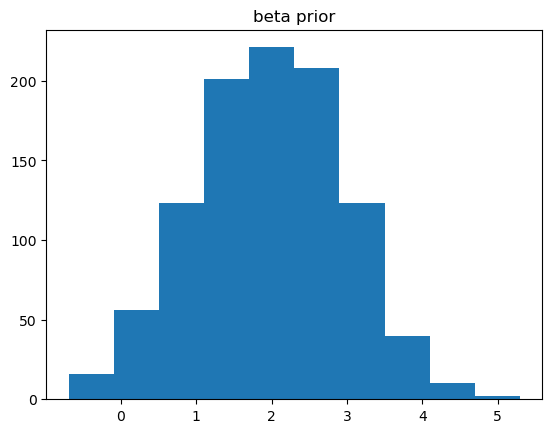

In [22]:
# TODO: plot the normal priors.
gamma_prior = np.random.normal(0.4, 0.5, size = 1000)
plt.hist(gamma_prior)
plt.title("gamma prior")
plt.show()
beta_prior = np.random.normal(2, 1, size = 1000)
plt.hist(beta_prior)
plt.title("beta prior")
plt.show()

In [23]:
# "observed" data
#bsi_pars = {"theta_C":0.6, "theta_BSI": 0.05, "mu_OR":0.4, "var_OR":0.6, "OR_size":100}
#params = {"S0": 100000 - 1, "I0": 1, "R0":0, "times":[i for i in range(0,104)],"timestep":1, "N":100000}
#pSIR_obs = propSIR_simulator(beta = 0.72, gamma = 0.2) # This is what I would need from the observational model
#print(pSIR_obs[1])
bs = 10
bsi_obs = get_obs_BSI(df = norm_data, clade = "A")
bsi_obs = bsi_obs[~np.isnan(bsi_obs)] # just omit nan:s for now
pSIR_obs = np.array([list(bsi_obs)]*bs)  #, np.array([list(1-bsi_obs)]*bs)) # JATKA TÄSTÄ!!!
#print(pSIR_obs)
#pSIR_obs = obsSI(or_data, clade = "C1", dataset = "BSAC", n_obs = len(params["times"]))#propSIR_simulator(beta = 0.72, gamma = 0.2) # This is what I would need from the observational model

test_obs = propSIR_simulator(beta = 0.72, gamma = 0.2, is_bsi = False)
print(test_obs)
print("haloo")#theta_bsi_a_obs = np.full((104, 3), 75/3179)

test_obs
pSIR_obs

(1, 104)
(array([[0.99999   , 0.9999828 , 0.99997186, 0.99995522, 0.99992994,
        0.99989151, 0.9998331 , 0.99974433, 0.99960943, 0.99940442,
        0.99909293, 0.99861975, 0.99790117, 0.99681042, 0.99515593,
        0.99264909, 0.98885701, 0.98313505, 0.97453365, 0.96167743,
        0.9426264 , 0.91475772, 0.87476692, 0.8189854 , 0.74431317,
        0.6500048 , 0.53998096, 0.42408478, 0.31587982, 0.22679317,
        0.16107666, 0.1161158 , 0.08642807, 0.06690276, 0.05387081,
        0.04497057, 0.03873856, 0.03427003, 0.03099731, 0.02855612,
        0.02670679, 0.02528757, 0.02418669, 0.02332516, 0.02264601,
        0.02210744, 0.02167826, 0.02133488, 0.02105925, 0.02083742,
        0.0206585 , 0.02051392, 0.02039694, 0.02030217, 0.02022532,
        0.02016295, 0.02011231, 0.02007116, 0.02003772, 0.02001052,
        0.01998841, 0.01997041, 0.01995577, 0.01994386, 0.01993416,
        0.01992627, 0.01991985, 0.01991461, 0.01991036, 0.01990689,
        0.01990407, 0.01990177, 0.0198

array([[0.02409639, 0.008     , 0.02362205, 0.00714286, 0.01886792,
        0.01041667, 0.0255102 , 0.01351351, 0.03971119, 0.04705882,
        0.04150943, 0.01320132, 0.02666667, 0.02535211],
       [0.02409639, 0.008     , 0.02362205, 0.00714286, 0.01886792,
        0.01041667, 0.0255102 , 0.01351351, 0.03971119, 0.04705882,
        0.04150943, 0.01320132, 0.02666667, 0.02535211],
       [0.02409639, 0.008     , 0.02362205, 0.00714286, 0.01886792,
        0.01041667, 0.0255102 , 0.01351351, 0.03971119, 0.04705882,
        0.04150943, 0.01320132, 0.02666667, 0.02535211],
       [0.02409639, 0.008     , 0.02362205, 0.00714286, 0.01886792,
        0.01041667, 0.0255102 , 0.01351351, 0.03971119, 0.04705882,
        0.04150943, 0.01320132, 0.02666667, 0.02535211],
       [0.02409639, 0.008     , 0.02362205, 0.00714286, 0.01886792,
        0.01041667, 0.0255102 , 0.01351351, 0.03971119, 0.04705882,
        0.04150943, 0.01320132, 0.02666667, 0.02535211],
       [0.02409639, 0.008     , 0.0

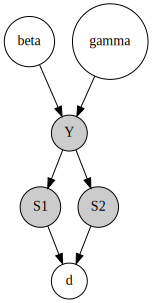

In [24]:
elfi.new_model()

# Define priors
beta = elfi.Prior(scipy.stats.norm, 2, 1) 
gamma = elfi.Prior(scipy.stats.norm, 0.4, 0.5) 
 

Y = elfi.Simulator(propSIR_simulator, beta, gamma, observed = pSIR_obs)
S1 = elfi.Summary(I_mean_bsi, Y)
S2 = elfi.Summary(I_var_bsi, Y)
#S3 = elfi.Summary(S_min_bsi, Y) # not needed, can find beta and gamma without this
#S4 = elfi.Summary(R_max, Y)
#S5 = elfi.Summary(theta_bsi_a, Y) # todo fix this; or test only this? No unique solution though I think.

#S2 = elfi.Summary(np.var, Y)
#d = elfi.Distance('euclidean', S1, S2, S3)
d = elfi.Distance('euclidean', S1,S2) #S1, S2, S3, S5)#,S3) #, S3, S4)
#d = elfi.Discrepancy(theta_bsi_a_distance, S5, theta_bsi_a_obs)
elfi.draw(d)

In [25]:
seed = 10
#rej = elfi.Rejection(d, seed=seed)
#smc = elfi.SMC(d, batch_size=10, seed=seed)
smc = elfi.AdaptiveThresholdSMC(d, batch_size=bs, seed=2, q_threshold=0.995)

In [26]:
S1.generate(batch_size = bs)
#print(S2.generate())

(10, 104)


 /tmp/ipykernel_6909/31183306.py:19: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_6909/31183306.py:25: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_6909/3936396446.py:39: RuntimeWarning:invalid value encountered in divide


array([[           nan],
       [9.16965988e-08],
       [           nan],
       [1.36262328e-01],
       [1.04875557e-02],
       [4.96823906e-02],
       [3.25637582e-02],
       [6.49199805e-01],
       [1.49114904e-07],
       [1.01071438e-07]])

In [310]:
S2.generate(batch_size = bs).shape

 /tmp/ipykernel_4114/31183306.py:19: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_4114/31183306.py:25: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_4114/2927414021.py:39: RuntimeWarning:invalid value encountered in divide


(10, 1)

In [311]:
pSIR_obs.shape

(10, 14)

In [312]:
d.generate(batch_size = bs)

 /tmp/ipykernel_4114/31183306.py:19: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_4114/31183306.py:25: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_4114/31183306.py:25: RuntimeWarning:invalid value encountered in subtract
 /tmp/ipykernel_4114/2927414021.py:39: RuntimeWarning:invalid value encountered in divide


array([[0.01424237, 0.01424237, 0.01424237, 0.01424237, 0.01424237,
        0.01424237, 0.01424237, 0.01424237, 0.01424237, 0.01424237],
       [0.01390496, 0.01390496, 0.01390496, 0.01390496, 0.01390496,
        0.01390496, 0.01390496, 0.01390496, 0.01390496, 0.01390496],
       [5.31975766, 5.31975766, 5.31975766, 5.31975766, 5.31975766,
        5.31975766, 5.31975766, 5.31975766, 5.31975766, 5.31975766],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.01444812, 0.01444812, 0.01444812, 0.01444812, 0.01444812,
        0.01444812, 0.01444812, 0.01444812, 0.01444812, 0.01444812],
       [0.00938296, 0.00938296, 0.00938296, 0.00938296, 0.00938296,
        0.00938296, 0.00938296, 0.00938296, 0.00938296, 0.00938296],
       [0.62339536, 0.62339536, 0.62339536, 0.62339536, 0.62339536,
        0.62339536, 0.62339536, 0.62339536, 0.62339536, 0.62339536],
       [0.0191699 , 0.0191699 , 0.0191699

In [315]:
# SMC-ABC alternativeS
#thresholds = [0.02]
#smc_samples = smc.sample(200, thresholds=thresholds)

smc_samples = smc.sample(1000, max_iter=10)

TypeError: '<' not supported between instances of 'float' and 'NoneType'

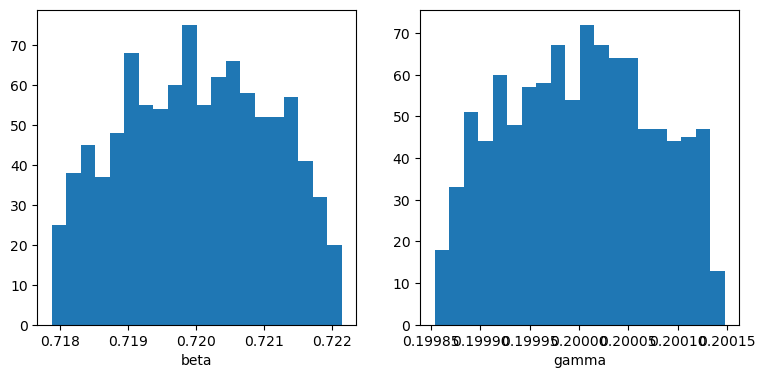

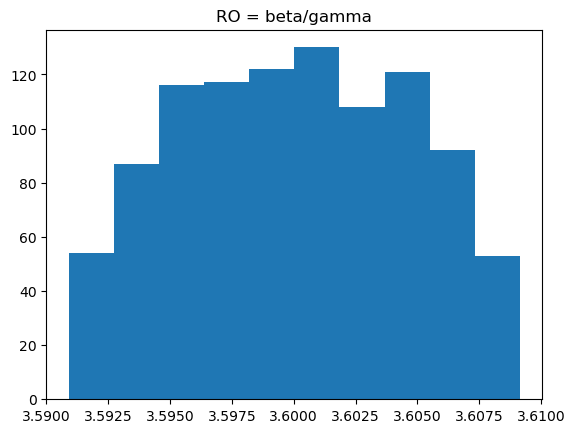

In [316]:
# current R0
print("R0:", smc_samples.samples['beta'].mean()/smc_samples.samples['gamma'].mean())


print(smc_samples)


smc_samples.plot_pairs()
plt.show()

plt.hist(smc_samples.samples['beta']/smc_samples.samples['gamma'])
plt.title("RO = beta/gamma")
plt.show()

In [ ]:
#adj = elfi.adjust_posterior(sample=smc_samples, model=elfi.get_model(), summary_names=['S1'])


$$R_0 = \frac{\beta}{\gamma}$$


In [99]:

# adaptive threshold, 100 samples, max_iter = 10, batch_size = 10
print(0.428/0.3)
print(1.191/0.873)
print(1.932/1.462)

# adaptive threshold, 1000 samples, beta ~ N(2,1) and gamma ~ N(0.4, 0.5)
print(0.479/0.268)
print(1.479/0.904)
print(2.573/1.616)

# adaptive threshold, uniform priors, beta ~ U(0,5) and gamma ~ U(0,3)
print(0.679/0.456)
print(2.653/1.869)
print(4.198/2.931)


R0 1.5525057641296922
Method: AdaptiveThresholdSMC
Number of samples: 1000
Number of simulations: 37350
Threshold: 0.28
Parameter                Mean               2.5%              97.5%
beta:                   1.479              0.479              2.573
gamma:                  0.904              0.268              1.616


1.4266666666666667
1.3642611683848798
1.3214774281805746
1.7873134328358207
1.636061946902655
1.5922029702970295
1.4890350877192984
1.4194756554307115
1.432275673831457


In [96]:
N = 200
#vis = dict(xlim=[-4,4], ylim=[-4,4])
%time result = rej.sample(N, quantile=0.01)

 /tmp/ipykernel_10957/3318330508.py:19: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_10957/3318330508.py:25: RuntimeWarning:overflow encountered in multiply
 /tmp/ipykernel_10957/3318330508.py:25: RuntimeWarning:invalid value encountered in subtract


Progress [==================================================] 100.0% Complete
CPU times: user 44.2 s, sys: 4.94 s, total: 49.2 s
Wall time: 43.7 s


In [102]:
print(result.samples['beta'].mean())
print(result.samples['gamma'].mean())
print("R0:", result.samples['beta'].mean()/result.samples['gamma'].mean())
result.summary()

1.3316228915740356
0.8962241936479971
R0: 1.4858144881737556
Method: Rejection
Number of samples: 200
Number of simulations: 20000
Threshold: 0.0482
Parameter                Mean               2.5%              97.5%
beta:                   1.332              0.448              2.328
gamma:                  0.896              0.286              1.577



array([[<AxesSubplot: ylabel='beta'>, <AxesSubplot: >],
       [<AxesSubplot: xlabel='beta', ylabel='gamma'>,
        <AxesSubplot: xlabel='gamma'>]], dtype=object)

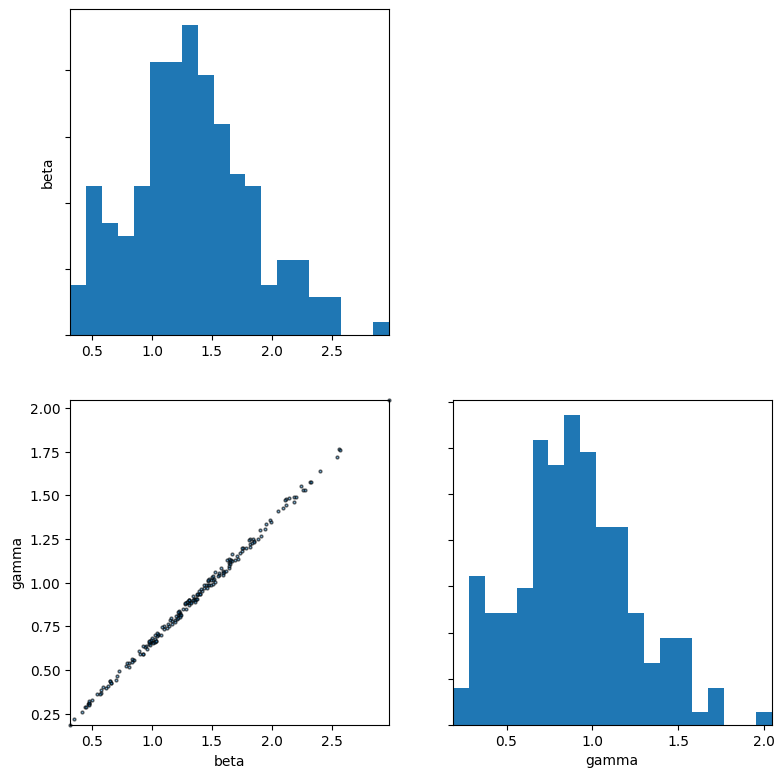

In [103]:
result.plot_pairs()

In [ ]:
#print(np.mean(propSIR_simulator(beta = 1.036, gamma = 0.007)))
print(np.mean(propSIR(beta = result.samples['beta'].mean(), gamma = result.samples['gamma'].mean(), params=params, bsi_params=bsi_pars, is_bsi = True)))

In [ ]:
1.036/0.007

In [ ]:
0.72/0.2

In [ ]:
# let's make a simpler SIR for this
def simpleSIR(beta, alpha, nt = 100, N = 1000, batch_size = 1, random_state = None):
    
    # Use fixed initial values
    S = [N - 1]
    I = [1]
    R = [0]
    
    # Use a fixed length sequence
    T = [i for i in range(0,nt)]
    N = [N]*(len(T) - 1) #*(len(T)-1) # Assume a fixed population size over time.
    
    for t in T[0:(len(T)-1)]: # could this be vectorized for efficiency?
        
        # Update SIR model
        I.append(I[t] + dI(I, S, t, beta, alpha, N))
        R.append(R[t] + dR(I, t, alpha))
        S.append(S[t] + dS(S, I, t, beta, N))
        
    #return S, I, R
    return I
def sse(y1, y2):
    
    (np.array(y1) - np.array(y2))**2
    
def sumstat(y):
    
    #return np.mean(y)
    return np.max(y)

# Define simulator (can ELFI handle multiple y:s?)
SIR_obs = simpleSIR(beta = 0.5, alpha = 0.2, nt=104)

T = [i for i in range(0,104)] # 1 t = 1 week
plt.plot(T, SIR_obs)
plt.title("SIR obs, I")
plt.xlabel("t (weeks)")
plt.show()

# Questions

**Q**: Onko batch-size argumentti tarpeellinen? Jokainen SIR simulaatio tuottaa täsmälleen saman käyrän eli eipä ole kovin stokastistista tämä :( Tai periaatteessa voin vain käyttää jotain `rep` tyyppistä funktiota suoraan.


# SIR model with a carrier compartment
